In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd "/content/drive/MyDrive/Early-Sepsis-Detection"

Mounted at /content/drive
/content/drive/MyDrive/Early-Sepsis-Detection


# 03 — Exploratory Data Analysis
### Early Sepsis Detection — Phase 4

Uses the cleaned dataset from `data/interim/sepsis_hourly_cleaned.parquet`
(1,552,210 rows x 45 columns, produced by `02_data_cleaning.ipynb`).

**Scope:** target prevalence, numerical/categorical variable distributions,
correlation structure, and sepsis vs. non-sepsis clinical time-series trends.
No unsupported medical claims are made — only patterns actually observed in
this dataset are described.


In [2]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)


In [3]:
cleaned_path = config.INTERIM_DIR / "sepsis_hourly_cleaned.parquet"
df = pd.read_parquet(cleaned_path)
print("Loaded shape:", df.shape)

# Patient-level label: 1 if the patient was ever SepsisLabel==1 at any hour
patient_label = df.groupby(config.PATIENT_ID_COL)[config.TARGET_COL].max().rename("patient_sepsis")
df = df.merge(patient_label, on=config.PATIENT_ID_COL, how="left")
print(df[['patient_id', 'patient_sepsis']].drop_duplicates().shape)


Loaded shape: (1552210, 45)
(40336, 2)


## 1. Target analysis

**What?** Sepsis prevalence at both the observation (hour) level and the
patient level, already computed exactly in Phase 2/3 — reproduced here on
the cleaned data as a consistency check and for the visuals below.


Observation-level prevalence: 1.798%
Patient-level prevalence:     7.269%


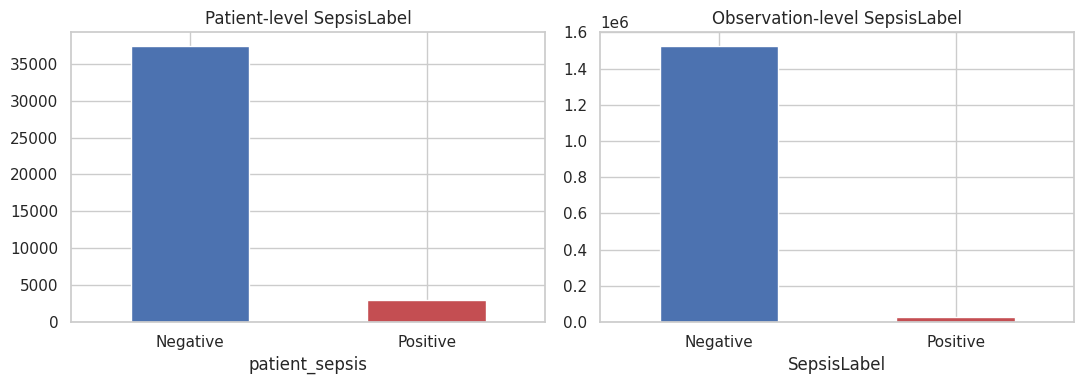

In [4]:
obs_prevalence = df[config.TARGET_COL].mean() * 100
patient_prevalence = patient_label.mean() * 100
print(f"Observation-level prevalence: {obs_prevalence:.3f}%")
print(f"Patient-level prevalence:     {patient_prevalence:.3f}%")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
patient_label.value_counts().sort_index().plot(kind="bar", ax=axes[0], color=["#4C72B0", "#C44E52"])
axes[0].set_xticklabels(["Negative", "Positive"], rotation=0)
axes[0].set_title("Patient-level SepsisLabel")

df[config.TARGET_COL].value_counts().sort_index().plot(kind="bar", ax=axes[1], color=["#4C72B0", "#C44E52"])
axes[1].set_xticklabels(["Negative", "Positive"], rotation=0)
axes[1].set_title("Observation-level SepsisLabel")
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "03_target_prevalence.png", dpi=150)
plt.show()


## 2. Numerical clinical variables

**What?** Distributions of a focused set of clinically important variables
(chosen for relatively low missingness, so the raw distribution reflects
real measurements rather than mostly-imputed values).

**Why these variables?** HR, Resp, Temp, MAP, O2Sat are the most complete
vitals (see Phase 2 missingness report); WBC, Lactate, Creatinine are
labs commonly cited in sepsis screening criteria (e.g. qSOFA/SIRS-adjacent
variables) and are included with the caveat that they are heavily
LOCF-filled by this point (see Phase 3), so distributions here reflect
carried-forward values, not only fresh measurements.


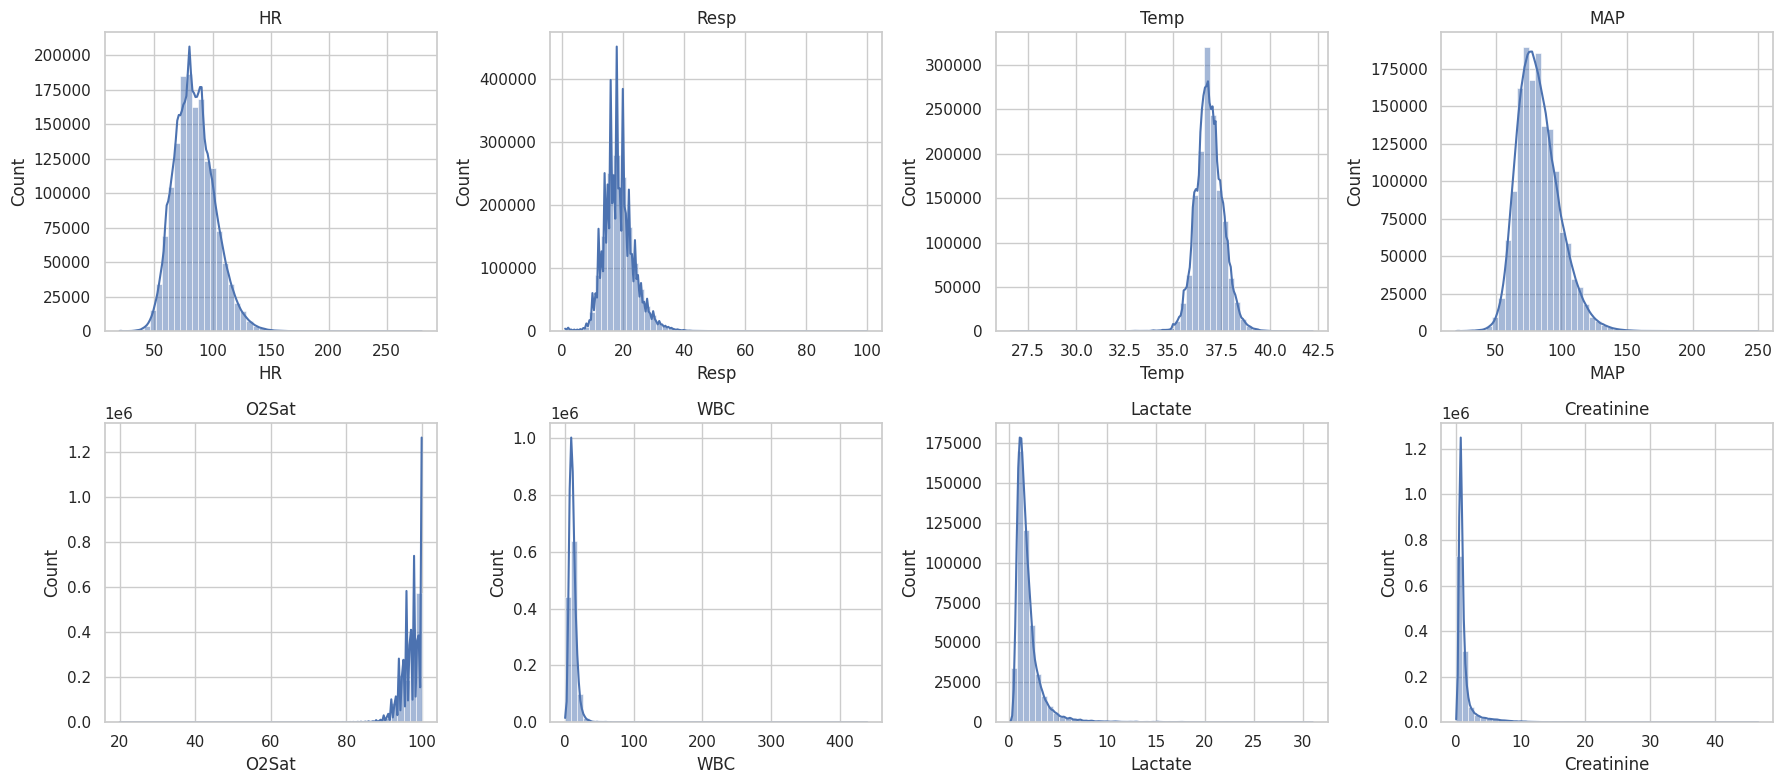

In [5]:
numerical_vars = ["HR", "Resp", "Temp", "MAP", "O2Sat", "WBC", "Lactate", "Creatinine"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, numerical_vars):
    sns.histplot(df[col].dropna(), bins=50, kde=True, ax=ax, color="#4C72B0")
    ax.set_title(col)
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "03_numerical_histograms.png", dpi=150)
plt.show()


/tmp/ipykernel_654/720092369.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df["patient_sepsis"], y=df[col], ax=ax, palette=["#4C72B0", "#C44E52"])
/tmp/ipykernel_654/720092369.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Negative", "Positive"])
/tmp/ipykernel_654/720092369.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df["patient_sepsis"], y=df[col], ax=ax, palette=["#4C72B0", "#C44E52"])
/tmp/ipykernel_654/720092369.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xtickl

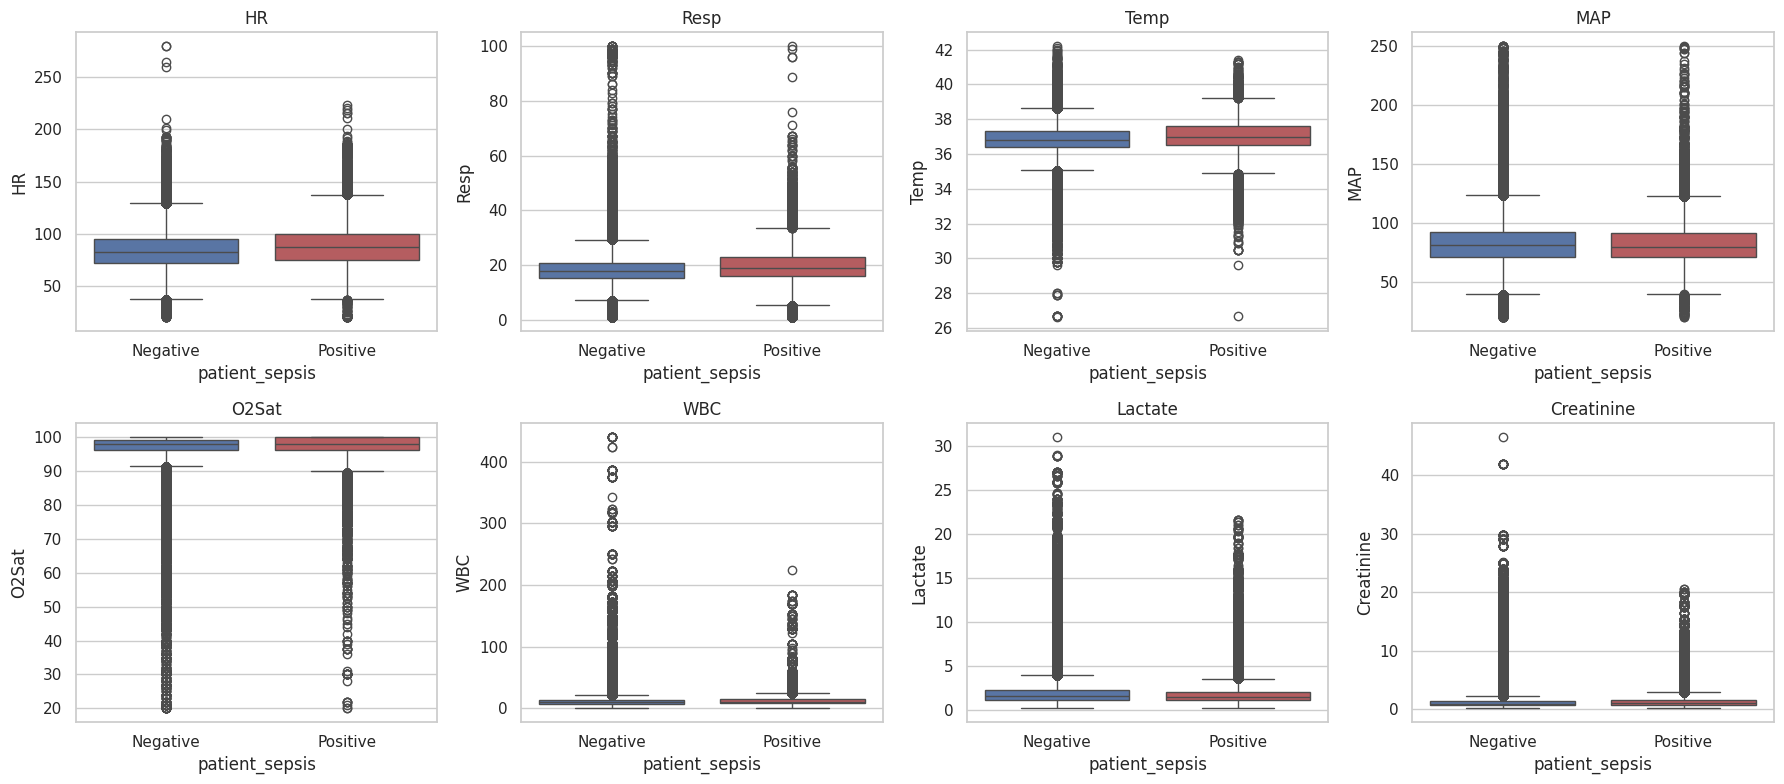

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, numerical_vars):
    sns.boxplot(x=df["patient_sepsis"], y=df[col], ax=ax, palette=["#4C72B0", "#C44E52"])
    ax.set_xticklabels(["Negative", "Positive"])
    ax.set_title(col)
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "03_numerical_boxplots_by_target.png", dpi=150)
plt.show()


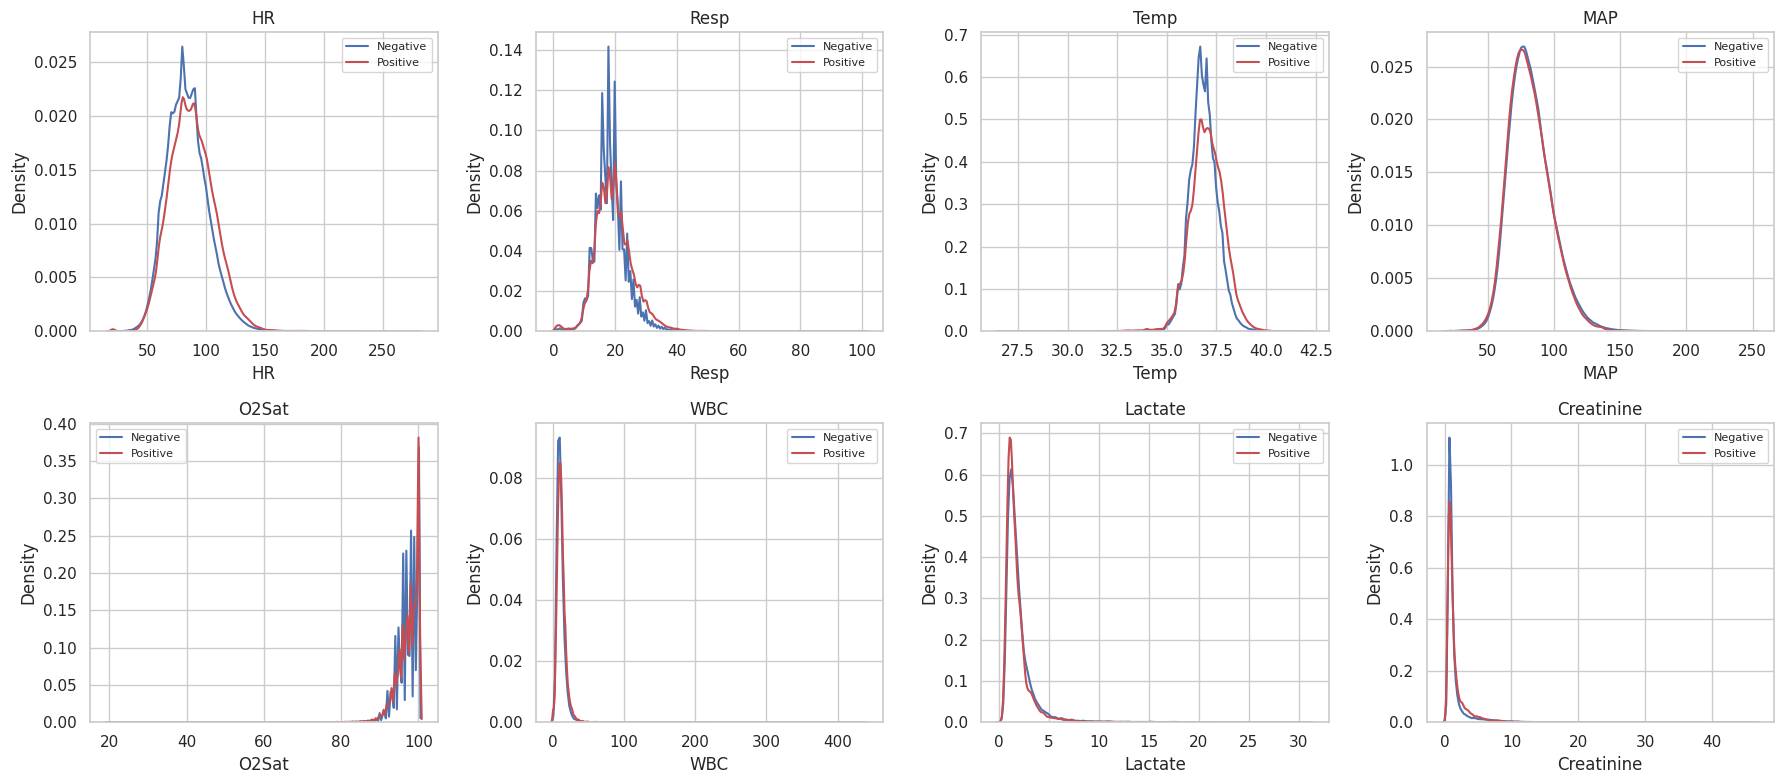

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, numerical_vars):
    for label, sub in df.groupby("patient_sepsis"):
        sns.kdeplot(sub[col].dropna(), ax=ax, label="Positive" if label == 1 else "Negative",
                    color="#C44E52" if label == 1 else "#4C72B0")
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "03_numerical_kde_by_target.png", dpi=150)
plt.show()


## 3. Categorical variables

**What?** Gender, Unit1, Unit2 (now including the explicit "Unknown"
sentinel from Phase 3) analyzed against patient-level sepsis status.


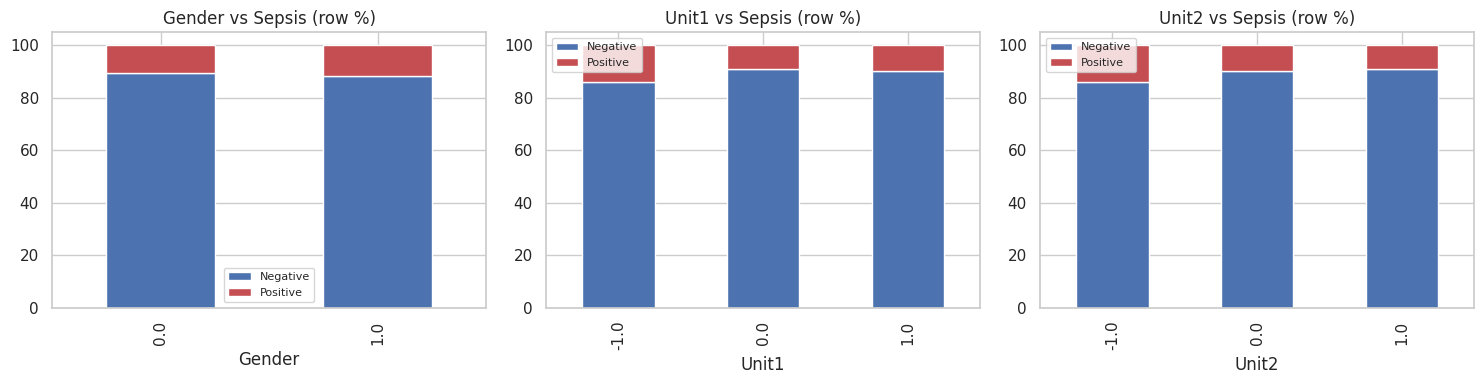

In [8]:
categorical_vars = ["Gender", "Unit1", "Unit2"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, categorical_vars):
    ct = pd.crosstab(df[col], df["patient_sepsis"], normalize="index") * 100
    ct.plot(kind="bar", stacked=True, ax=ax, color=["#4C72B0", "#C44E52"])
    ax.set_title(f"{col} vs Sepsis (row %)")
    ax.legend(["Negative", "Positive"], fontsize=8)
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "03_categorical_vs_target.png", dpi=150)
plt.show()


## 4. Correlation structure

**What?** Pairwise correlation among the numerical clinical variables
(Pearson, computed on rows with at least one non-missing pair — pandas
`.corr()` handles this pairwise by default).

**Caveat:** With this much LOCF-filled data, correlations partly reflect
shared measurement timing/frequency, not only physiology — interpret
with care, not as causal relationships.


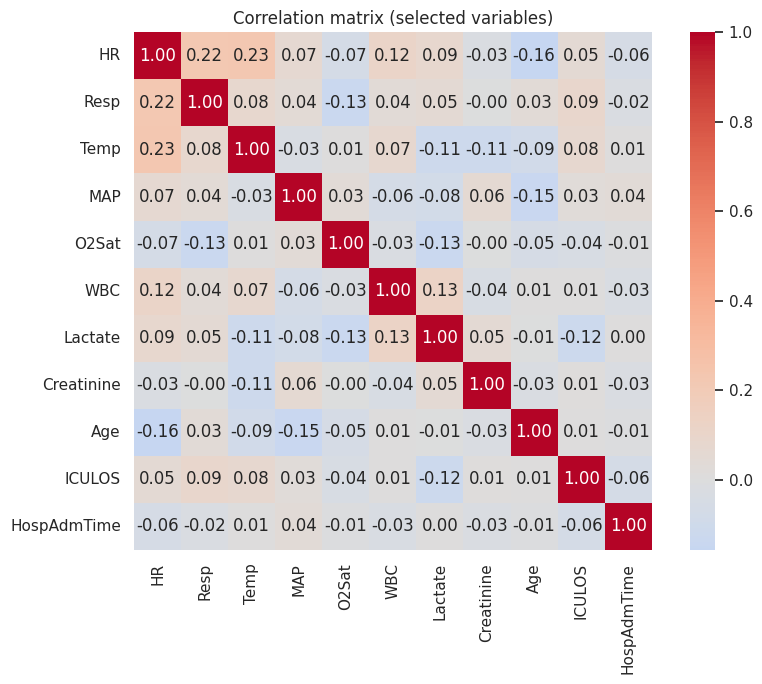

In [9]:
corr_vars = numerical_vars + ["Age", "ICULOS", "HospAdmTime"]
corr_matrix = df[corr_vars].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation matrix (selected variables)")
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "03_correlation_matrix.png", dpi=150)
plt.show()


In [10]:
# Highly correlated pairs (|r| > 0.6, excluding diagonal)
corr_unstacked = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)).stack()
high_corr = corr_unstacked[corr_unstacked.abs() > 0.6].sort_values(ascending=False)
print("Highly correlated pairs (|r| > 0.6):")
display(high_corr)


Highly correlated pairs (|r| > 0.6):


,,0


## 5. Clinical trends over ICU time: sepsis vs. non-sepsis

**What?** Mean trajectory of key variables by ICU hour (`ICULOS`), split by
patient-level sepsis status.

**Why?** This is the core time-series signal the later LSTM/GRU and
temporal features (Phase 8, 16) are meant to capture — visualizing it first
tells us whether there IS a visible divergence before relying on a model
to find one.

**Caution:** These are LOCF-filled values and reflect a *fixed ICU hour*,
not hours-before-sepsis-onset — a positive patient's trajectory here is
not aligned to their individual onset time. This is an exploratory,
descriptive view, not a claim about predictive lead time (that is handled
explicitly in Phase 7 — Target Construction).


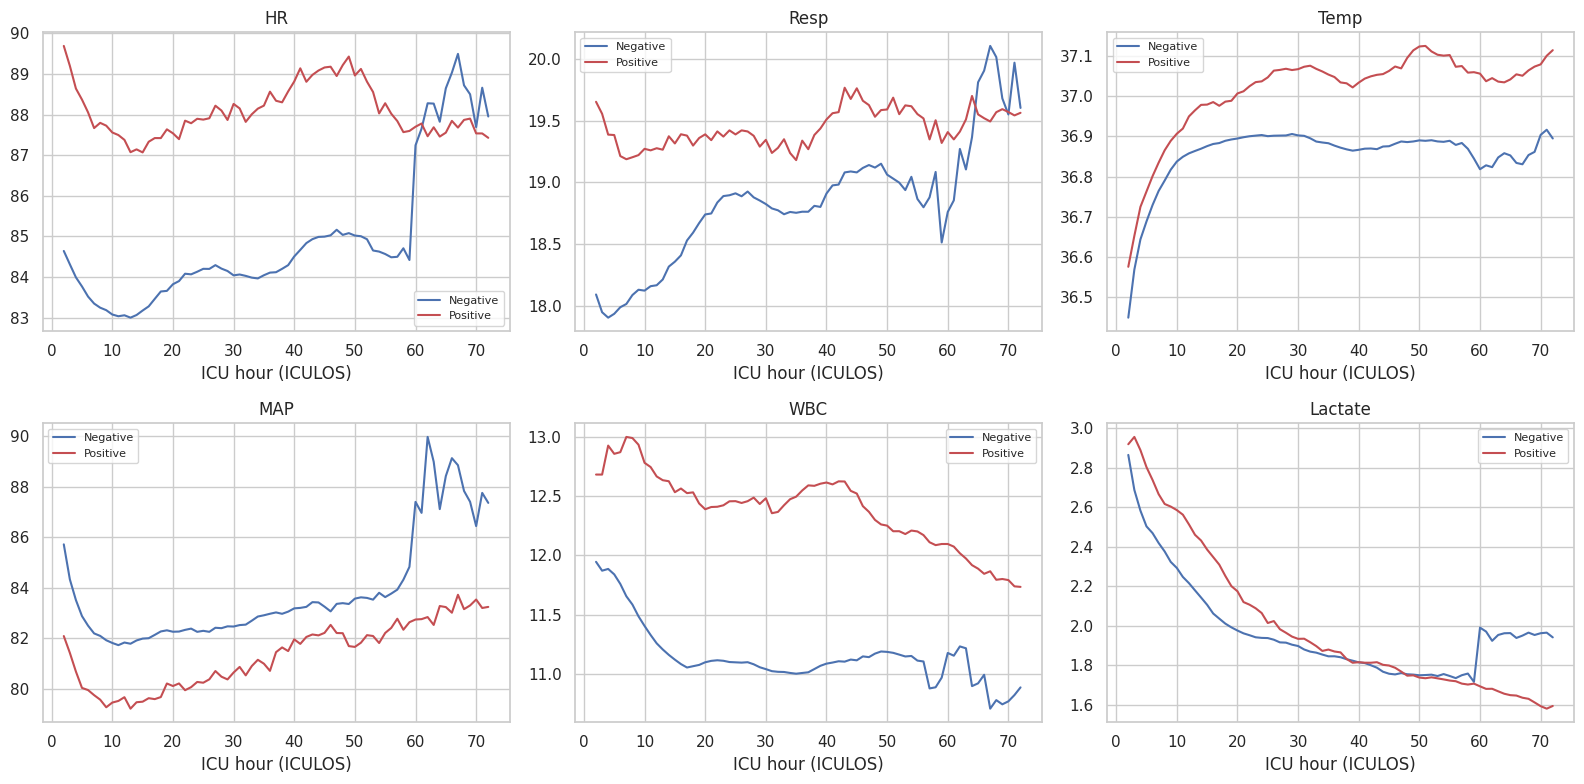

In [11]:
trend_vars = ["HR", "Resp", "Temp", "MAP", "WBC", "Lactate"]
max_hour = 72  # focus on the first 3 ICU days, where most patients still have data

trend_df = df[df["ICULOS"] <= max_hour]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, trend_vars):
    grouped = trend_df.groupby(["ICULOS", "patient_sepsis"])[col].mean().reset_index()
    for label, sub in grouped.groupby("patient_sepsis"):
        ax.plot(sub["ICULOS"], sub[col],
                label="Positive" if label == 1 else "Negative",
                color="#C44E52" if label == 1 else "#4C72B0")
    ax.set_title(col)
    ax.set_xlabel("ICU hour (ICULOS)")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "03_trends_sepsis_vs_nonsepsis.png", dpi=150)
plt.show()


## 6. Measurement frequency over time

**What?** How often each variable is actually re-measured (not LOCF-filled)
per ICU hour — a proxy for clinical attention/monitoring intensity.


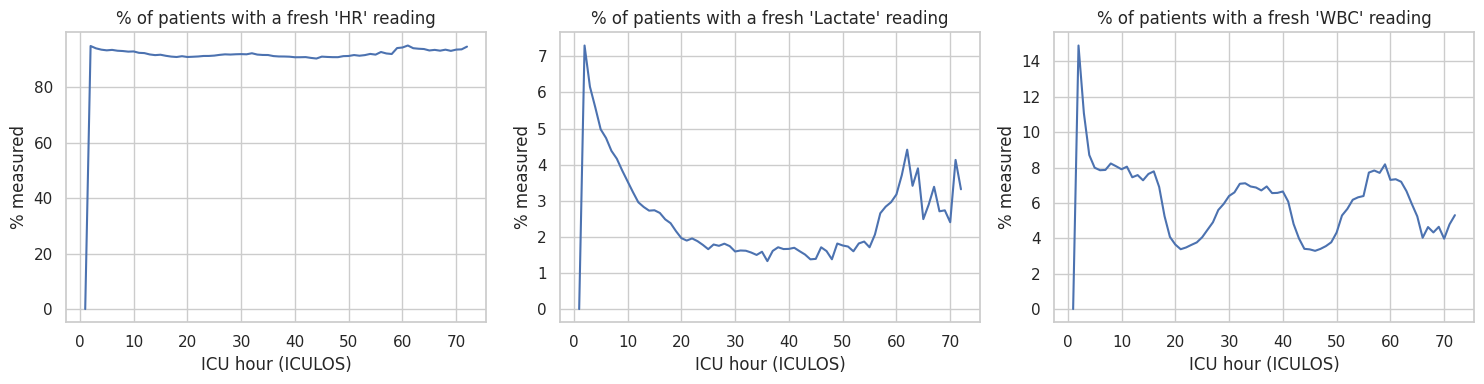

In [12]:
# Reload the PRE-LOCF cleaned-but-not-filled data would be ideal, but since LOCF was
# applied in Phase 3, we approximate measurement frequency using the long-format
# raw (pre-cleaning) cache instead, if available, for an honest frequency signal.
raw_cache = config.INTERIM_LONG_PARQUET
if raw_cache.exists():
    raw_df = pd.read_parquet(raw_cache, columns=["patient_id", "ICULOS", "HR", "Lactate", "WBC"])
    freq_df = raw_df[raw_df["ICULOS"] <= max_hour]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, col in zip(axes, ["HR", "Lactate", "WBC"]):
        measured_pct = freq_df.groupby("ICULOS")[col].apply(lambda s: s.notna().mean() * 100)
        ax.plot(measured_pct.index, measured_pct.values)
        ax.set_title(f"% of patients with a fresh '{col}' reading")
        ax.set_xlabel("ICU hour (ICULOS)")
        ax.set_ylabel("% measured")
    plt.tight_layout()
    plt.savefig(config.FIGURES_DIR / "03_measurement_frequency.png", dpi=150)
    plt.show()
else:
    print("Raw long-format cache not found — skipping measurement-frequency plot. "
          "Re-run 01_data_understanding.ipynb with save_parquet=True if needed.")


---
### What to send back to Claude after running this notebook

- Section 4's "highly correlated pairs" output (any |r| > 0.6 pairs)
- A brief description of whether Section 5's trend plots show visible
  divergence between sepsis-positive and negative patients for any variable
  (e.g. does HR or Lactate rise earlier/higher for positive patients?)
- Any errors, especially in Section 6 if the raw cache parquet isn't found

With that, we move to **Phase 5 (Missing Value Analysis deep-dive: MCAR/MAR/MNAR
discussion, missingness by sepsis status)** and **Phase 6 (formal Time-Series
Analysis)**, before Phase 7 (Target Construction) — which must be done carefully
to avoid leaking future information into the prediction target.
